In [303]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.pipeline import Pipeline


In [304]:
df = pd.read_csv("Housing.csv")
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [305]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [306]:
print(df.describe())

              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [307]:
print(df.shape)

(545, 13)


In [308]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


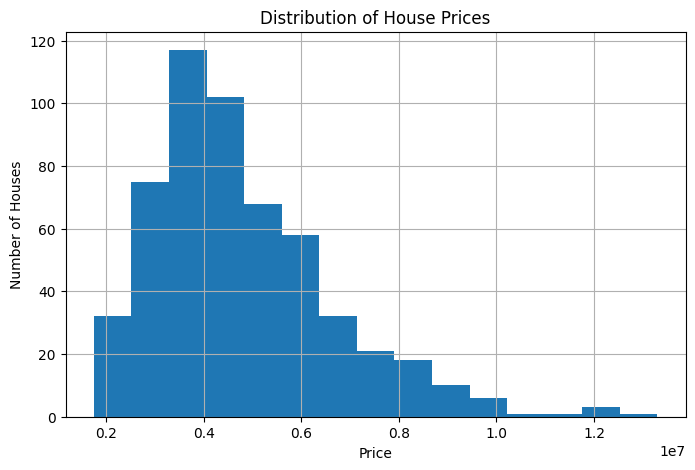

In [309]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=15)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.grid(True)
plt.show()

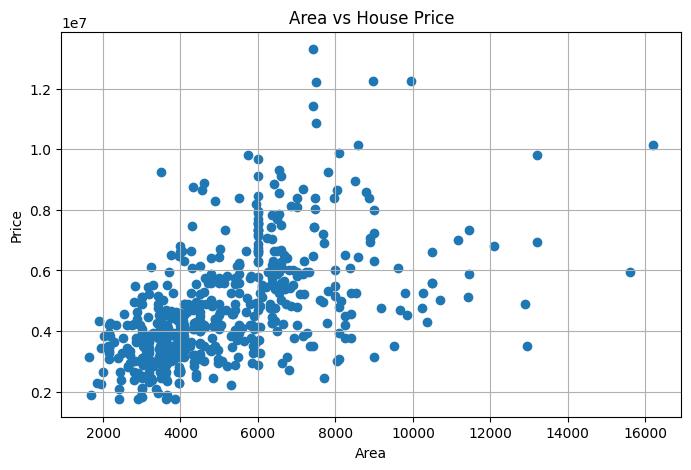

In [310]:
plt.figure(figsize=(8,5))
plt.scatter(df["area"], df["price"])
plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.grid(True)
plt.show()

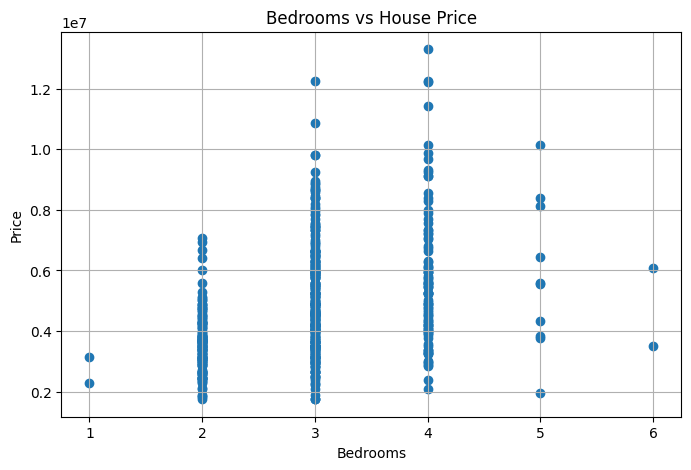

In [311]:
plt.figure(figsize=(8,5))
plt.scatter(df["bedrooms"], df["price"])
plt.title("Bedrooms vs House Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.grid(True)
plt.show()

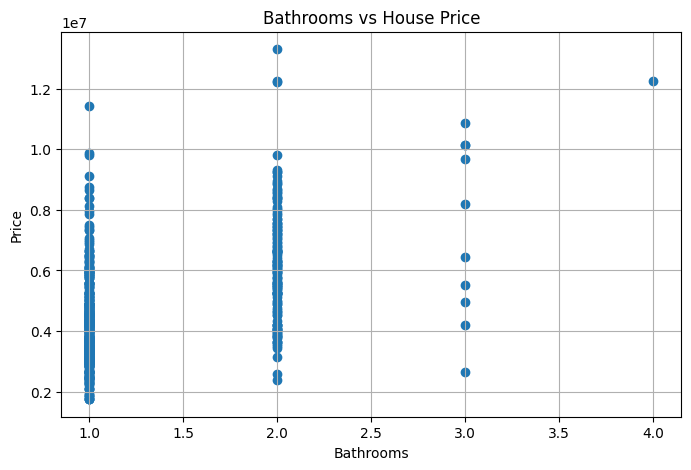

In [312]:
plt.figure(figsize=(8,5))
plt.scatter(df["bathrooms"], df["price"])
plt.title("Bathrooms vs House Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.grid(True)
plt.show()

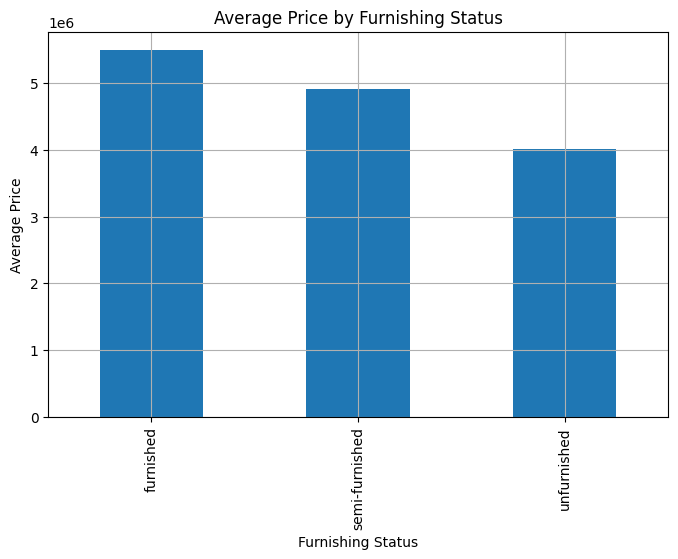

In [313]:
avg_price = df.groupby("furnishingstatus")["price"].mean()

plt.figure(figsize=(8,5))
avg_price.plot(kind="bar")

plt.title("Average Price by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Average Price")

plt.grid(True)
plt.show()

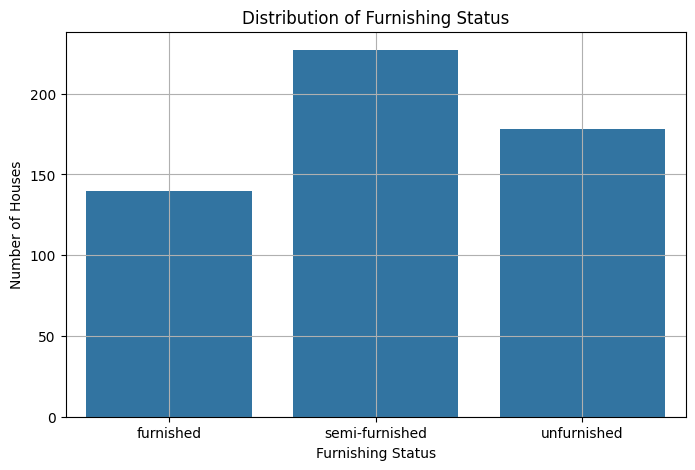

In [314]:
plt.figure(figsize=(8,5))
sns.countplot(x="furnishingstatus", data=df)
plt.title("Distribution of Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Number of Houses")
plt.grid(True)
plt.show()

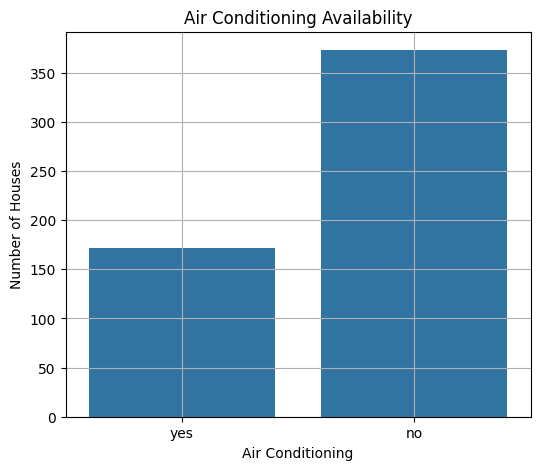

In [315]:
plt.figure(figsize=(6,5))
sns.countplot(x="airconditioning", data=df)

plt.title("Air Conditioning Availability")
plt.xlabel("Air Conditioning")
plt.ylabel("Number of Houses")
plt.grid(True)
plt.show()

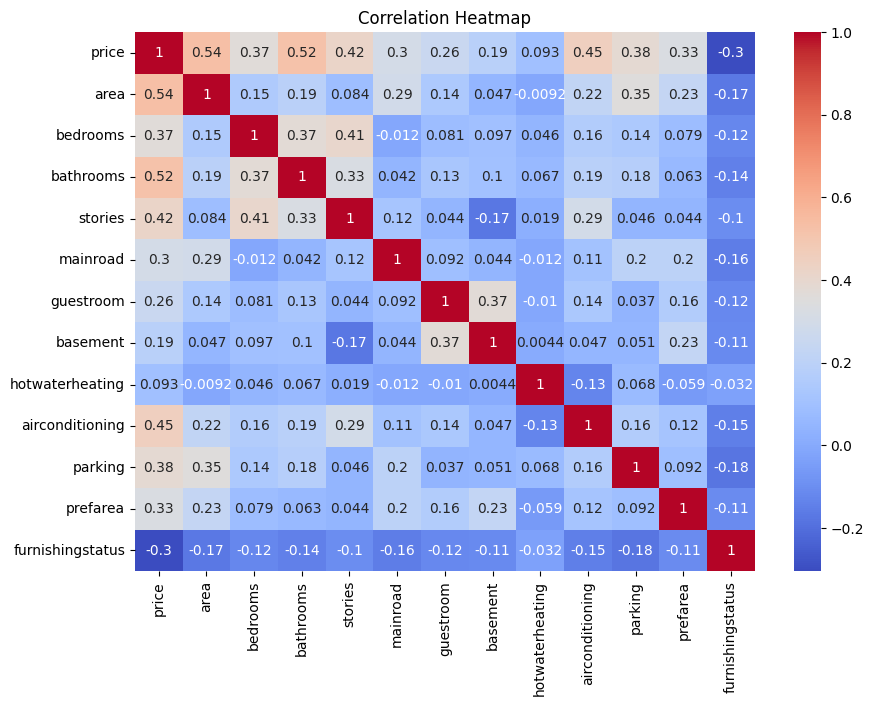

In [316]:
temp_df = df.copy()
le = LabelEncoder()

for col in temp_df.select_dtypes(include="object").columns:
    temp_df[col] = le.fit_transform(temp_df[col])

plt.figure(figsize=(10,7))
sns.heatmap(temp_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [317]:
corr_price = temp_df.corr()["price"]

print(corr_price.sort_values(ascending=False))

price               1.000000
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
furnishingstatus   -0.304721
Name: price, dtype: float64


In [318]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include="object").columns:
    encoder = LabelEncoder()
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [319]:
X = df_encoded.drop("price", axis=1)
Y = df_encoded["price"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.2, random_state=50)

In [320]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MODEL 1 - LINEAR REGRESSION

In [321]:
lr = LinearRegression()
lr.fit(X_train_scaled, Y_train)
Y_pred_lr = lr.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_lr))
lr_r2 = r2_score(Y_test, Y_pred_lr)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

RMSE: 898804.1158340364
R2: 0.7624579467323473


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


MODEL 2 - DECISION TREE REGRESSOR

In [322]:
dt = DecisionTreeRegressor(random_state=50)
dt.fit(X_train_scaled,Y_train)
Y_pred_dt = dt.predict(X_test_scaled)

dt_rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_dt))
dt_r2 = r2_score(Y_test,Y_pred_dt)

print("RMSE:", dt_rmse)
print("R2:", dt_r2)

RMSE: 1706018.5645873006
R2: 0.1441889164973451


MODEL 3 - RANDOM FOREST REGRESSOR

In [323]:
rf = RandomForestRegressor(n_estimators=100, random_state=50)
rf.fit(X_train_scaled, Y_train)
Y_pred_rf = rf.predict(X_test_scaled)

rf_rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_rf))
rf_r2 = r2_score(Y_test, Y_pred_rf)

print("RMSE:", rf_rmse)
print("R2:", rf_r2)

RMSE: 936839.107655136
R2: 0.7419282750651683


In [324]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

print(results)

               Model          RMSE        R2
0  Linear Regression  8.988041e+05  0.762458
1      Decision Tree  1.706019e+06  0.144189
2      Random Forest  9.368391e+05  0.741928


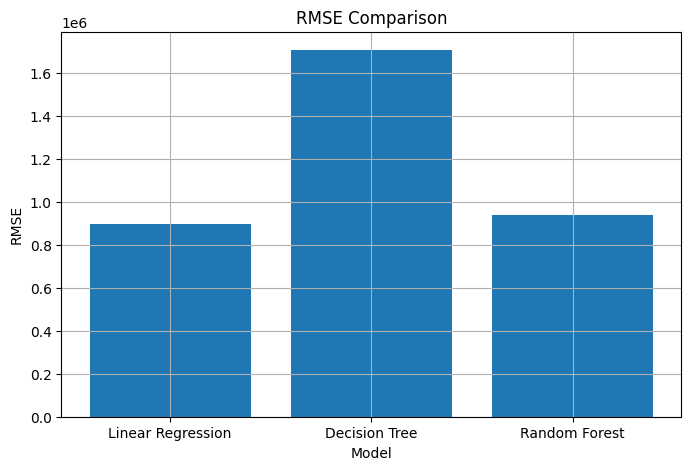

In [325]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

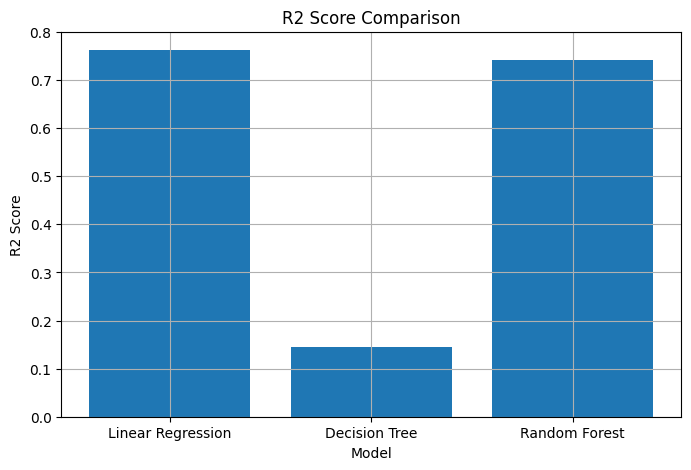

In [326]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R2"])
plt.title("R2 Score Comparison")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.grid(True)
plt.show()

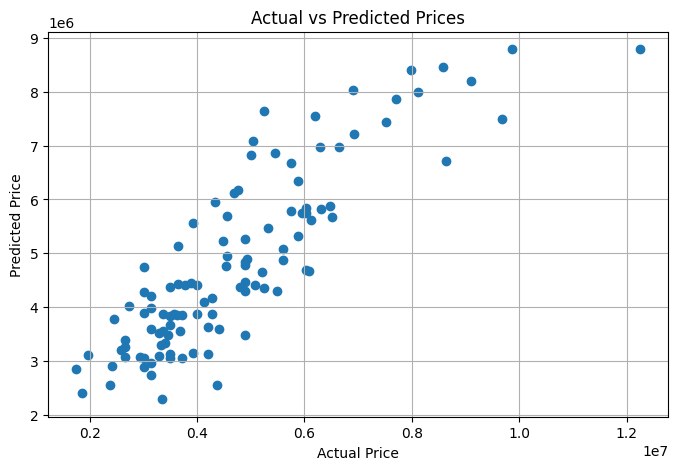

In [327]:
plt.figure(figsize=(8,5))
plt.scatter(Y_test, Y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()

In [328]:
kf = KFold(n_splits=5, shuffle=True, random_state=50)

scores = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=50),
    X,
    Y,
    cv=kf,
    scoring="r2"
)
print("Cross Validation Scores")
print(scores)
print()
print("Average R2")
print(scores.mean())

Cross Validation Scores
[0.73536575 0.6557715  0.51450187 0.59129334 0.61717047]

Average R2
0.6228205873356547


In [329]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance)

             Feature  Importance
0               area    0.457117
2          bathrooms    0.149166
9            parking    0.067449
3            stories    0.059429
11  furnishingstatus    0.057934
8    airconditioning    0.057354
1           bedrooms    0.040833
10          prefarea    0.035622
6           basement    0.029199
7    hotwaterheating    0.018109
5          guestroom    0.017221
4           mainroad    0.010566


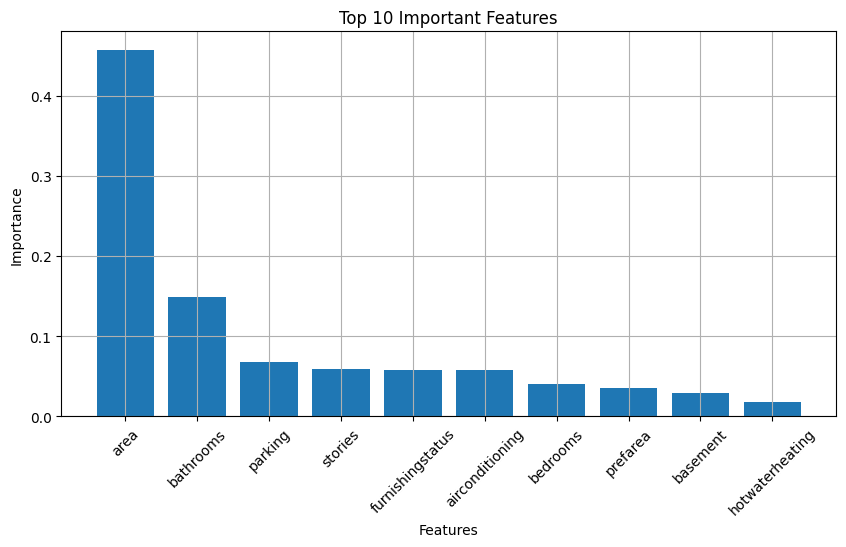

In [330]:
top10 = feature_importance.head(10)
plt.figure(figsize=(10,5))
plt.bar(top10["Feature"], top10["Importance"])
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [331]:
pipeline = Pipeline([
    ("scaler",StandardScaler()),
    ("model",LinearRegression())
])

pipeline.fit(X_train,Y_train)
pipeline_pred = pipeline.predict(X_test)
pipeline_r2 = r2_score(Y_test,pipeline_pred)
print("Pipeline R2:",pipeline_r2)

Pipeline R2: 0.7624579467323473


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [332]:
tree_values = [
    50,
    100,
    150,
    200
]

r2_scores = []

for n in tree_values:

    model = RandomForestRegressor(n_estimators=n,random_state=50)

    model.fit(X_train_scaled,Y_train)
    pred = model.predict(X_test_scaled)
    score = r2_score(Y_test, pred)
    r2_scores.append(score)
    print("Trees:",n,"R2:",score)

Trees: 50 R2: 0.7391093739538436
Trees: 100 R2: 0.7419282750651683
Trees: 150 R2: 0.7406240507469339
Trees: 200 R2: 0.7397532984069684


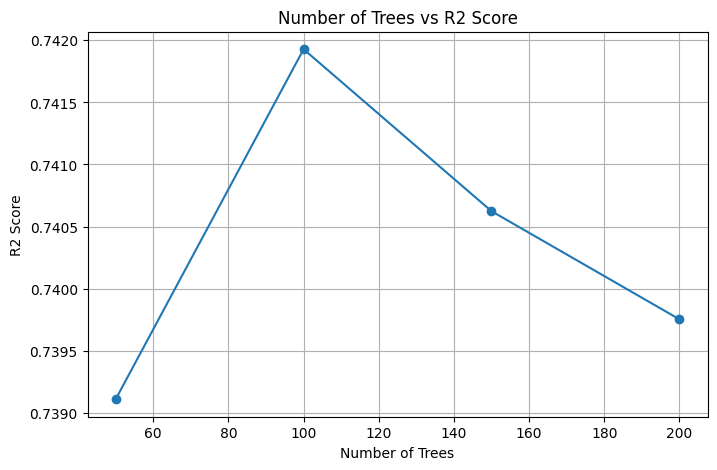

In [333]:
plt.figure(figsize=(8,5))
plt.plot(
    tree_values,
    r2_scores,
    marker="o"
)

plt.title("Number of Trees vs R2 Score")
plt.xlabel("Number of Trees")
plt.ylabel("R2 Score")
plt.grid(True)
plt.show()

In [334]:
depths = [3, 5, 7, 10, 15]
depth_scores = []

for d in depths:

    rf_depth = RandomForestRegressor(n_estimators=100, max_depth=d,random_state=50)
    rf_depth.fit(X_train_scaled, Y_train)
    pred = rf_depth.predict(X_test_scaled)
    score = r2_score(Y_test, pred)
    depth_scores.append(score)
    print("Depth:",d,"R2:",round(score,4))

Depth: 3 R2: 0.652
Depth: 5 R2: 0.7279
Depth: 7 R2: 0.7462
Depth: 10 R2: 0.7487
Depth: 15 R2: 0.7396


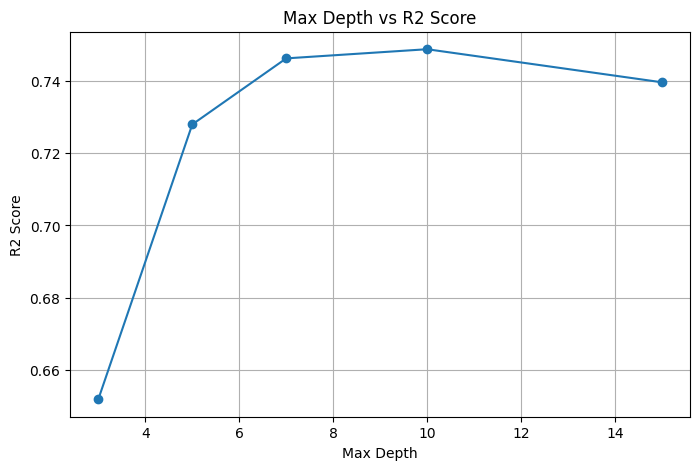

In [335]:
plt.figure(figsize=(8,5))
plt.plot(
    depths,
    depth_scores,
    marker="o"
)

plt.title("Max Depth vs R2 Score")
plt.xlabel("Max Depth")
plt.ylabel("R2 Score")
plt.grid(True)
plt.show()

In [336]:
best_depth = depths[depth_scores.index(max(depth_scores))]
print("Best Depth:",best_depth)
print("Best R2:",max(depth_scores))

Best Depth: 10
Best R2: 0.7487216019433518


In [337]:
best_overall_r2 = max(max(r2_scores),max(depth_scores))

comparison = pd.DataFrame({
    "Version":[
        "Default RF",
        "Tuned RF"
    ],
    "R2":[
        rf_r2,
        best_overall_r2
    ]
})

print(comparison)
print()
print("Improvement:",round(best_overall_r2 - rf_r2,5))

      Version        R2
0  Default RF  0.741928
1    Tuned RF  0.748722

Improvement: 0.00679


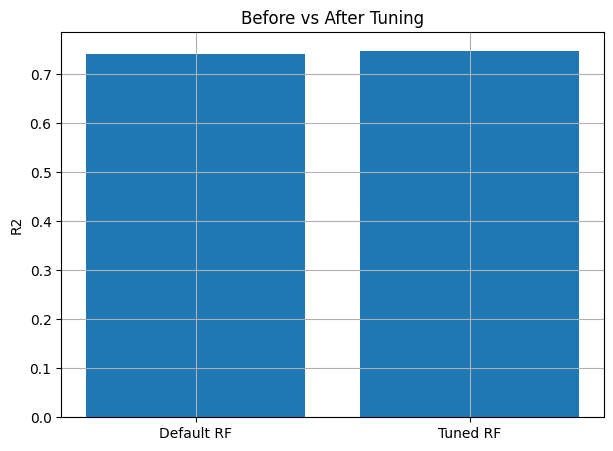

In [338]:
plt.figure(figsize=(7,5))

plt.bar(
    comparison["Version"],
    comparison["R2"]
)

plt.title("Before vs After Tuning")
plt.ylabel("R2")
plt.grid(True)
plt.show()

In [339]:
import joblib
joblib.dump(
    pipeline,
    "house_price_pipeline.pkl"
)

['house_price_pipeline.pkl']

In [340]:
sample_house = [[
    7000,
    4,
    3,
    2,
    1,
    0,
    1,
    0,
    1,
    2,
    1,
    2
]]

prediction = pipeline.predict(sample_house)
print("Predicted House Price:")
print(prediction[0])

Predicted House Price:
8542339.41513532


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
